# Assignment 1
## Author: Jan Pułtorak

In [1]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed);

## Taks 1 - Tensor Mechanics

### Initialization

In [2]:
n = 5
zeros = torch.zeros(n)
ones = torch.ones(n)

print("Zeros:", zeros)
print("Ones: ", ones)
ones.shape

Zeros: tensor([0., 0., 0., 0., 0.])
Ones:  tensor([1., 1., 1., 1., 1.])


torch.Size([5])

In [3]:
nrand = torch.normal(mean=0.0, std=1.0, size=(n, ))
urand = torch.rand(size = (n, ))
print("Random normal:", nrand)
print("Random uniform:", urand)

Random normal: tensor([ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229])
Random uniform: tensor([0.8694, 0.5677, 0.7411, 0.4294, 0.8854])


### Operations

1. `torch.mathmul` or @ - multiplication with broadcasting and batching, `torch.mm` - strictly for matrix (2D) multiplication.
2. `*` - elementwise multiplication.
3. `tensor.t()` - strict 2D transpose, `tensor.T` - reverse all dimensions, `tensor.mt` - swap only last two dimensions (good for batched), `torch.transpose(tensor, dim0, dim1) - transpose only selected dim0 and dim1 dimensions.

In [4]:
A = torch.tensor([
    [1, 2],
    [3, 4]
])
B = torch.tensor([
    [2, 1],
    [0, 1]
])

print(torch.mm(A, B))
A @ B

tensor([[2, 3],
        [6, 7]])


tensor([[2, 3],
        [6, 7]])

In [5]:
A * B

tensor([[2, 2],
        [0, 4]])

In [6]:
C = A @ B
print(C.t())
print(C.mT)
C.T

tensor([[2, 6],
        [3, 7]])
tensor([[2, 6],
        [3, 7]])


tensor([[2, 6],
        [3, 7]])

### Broadcasting, reshaping, concatenation
https://docs.pytorch.org/docs/stable/notes/broadcasting.html

In [7]:
x = torch.tensor([1, 2, 3], dtype=torch.uint8)
y = torch.zeros((2, 2, 3), dtype=torch.uint8)

res = x+y
x.shape, y.shape, res.shape

(torch.Size([3]), torch.Size([2, 2, 3]), torch.Size([2, 2, 3]))

In [8]:
res,

(tensor([[[1, 2, 3],
          [1, 2, 3]],
 
         [[1, 2, 3],
          [1, 2, 3]]], dtype=torch.uint8),)

In [9]:
x = torch.tensor([
    [1, 2],
    [3, 4],
    [5, 6],
    [7, 8]
])
x.reshape(8), x.reshape((2, 4)), x.reshape((2, 2, 2))

(tensor([1, 2, 3, 4, 5, 6, 7, 8]),
 tensor([[1, 2, 3, 4],
         [5, 6, 7, 8]]),
 tensor([[[1, 2],
          [3, 4]],
 
         [[5, 6],
          [7, 8]]]))

In [10]:
x = torch.tensor([
    [1, 2],
    [3, 4],
    [5, 6],
    [7, 8]
])

y = torch.tensor([
    [0, 0],
    [0, 0],
])

z = torch.tensor([
    [1, 1, 1],
    [2, 2, 2],
])
torch.cat((x, y), ), torch.cat((y, z), dim=1)

(tensor([[1, 2],
         [3, 4],
         [5, 6],
         [7, 8],
         [0, 0],
         [0, 0]]),
 tensor([[0, 0, 1, 1, 1],
         [0, 0, 2, 2, 2]]))

### Incorrect shape operations
Some examples:
1. When reshaping, the product of dimensions must be equal. Reshaping (2, 2) into (3, ) will fail
2. Broadcasting - each dimension must either be equal, one of them must be 1, or non existent. Cannot broadcast (3, 1) to  (6, 2, 2) because on second dimension $2 \neq 3$.

In [11]:
try:
    x = torch.tensor([
        [1, 2],
        [3, 4],
    ])
    x.reshape((3, ))
except Exception as e:
    print("ERROR:", e)


ERROR: shape '[3]' is invalid for input of size 4


In [12]:
try:
    x = torch.zeros((3, 1))
    y = torch.zeros((6, 2, 2))
    z = x + y
except Exception as e:
    print("ERROR:", e)

ERROR: The size of tensor a (3) must match the size of tensor b (2) at non-singleton dimension 1


### Manual linear algebra

In [13]:
def dot(v1: torch.Tensor, v2: torch.Tensor):
    res = 0
    for x, y in zip(v1, v2):
        res += x*y
    return res

def matrix_vector(A: torch.Tensor, v: torch.Tensor):
    m, n = tuple(A.shape)
    assert v.ndim == 1 and v.shape[0] == n

    res = torch.empty((m,))
    for i, row in enumerate(A):
        res[i] = dot(row, v)
    return res

def mat_mul(A: torch.Tensor, B: torch.Tensor):
    assert A.ndim == B.ndim == 2 and A.shape[1] == B.shape[0]
    m, n = A.shape
    _, p = B.shape

    res = torch.empty((m, p))
    for i in range(p):
        res[:, i] = matrix_vector(A, B[:, i])

    return res

def batched_matrix_mult(A: torch.Tensor, B: torch.Tensor):
    assert A.ndim == B.ndim == 3 and A.shape[0] == B.shape[0] and A.shape[2] == B.shape[1]
    b, m, n = A.shape
    _, _, p = B.shape

    res = torch.empty((b, m, p))
    for batch in range(b):
        res[batch] = mat_mul(A[batch], B[batch])

    return res


In [14]:
v1 = torch.tensor([1., 2., 3.])
v2 = 2 * torch.ones((3,))

assert torch.equal(v1 @ v2, dot(v1, v2))

In [15]:
A = torch.tensor([
    [2., 1.],
    [0., 1.]
])
v = torch.tensor([2., 5.])

assert torch.equal(A @ v, matrix_vector(A, v))

In [16]:
B1 = torch.tensor([
    [[1., 2.], [3., 4.]],
    [[5., 6.], [7., 8.]]
])
B2 = torch.tensor([
    [[1., 0.], [0., 1.]],
    [[2., 0.], [0., 2.]]
])

assert torch.equal(B1 @ B2, batched_matrix_mult(B1, B2))

## Task 2

In [17]:
class Model:
    def __init__(self, w=None, b=None):
        self.w, self.b = w, b
        if w is None:
            self.w = 10*torch.rand(1) - 5
        if b is None:
            self.b = 10*torch.rand(1) - 5

    def forward(self, x: torch.Tensor):
        return self.w*x + self.b

def mse(y_pred: torch.Tensor, y: torch.Tensor):
    assert y_pred.ndim == y.ndim == 1 and y_pred.shape[0] == y.shape[0]
    n = y.shape[0]
    return torch.sum((y-y_pred)**2) / n

source_m = Model(3, 1)
rand_m = Model()
print(rand_m.w, rand_m.b)

n = 100
x = torch.sort(20 * torch.rand(n) - 10).values

y_source = source_m.forward(x)
y_rand = rand_m.forward(x)
y = y_source + torch.normal(mean=0, std=1, size=(n,))


tensor([0.7390]) tensor([-2.3342])


In [18]:
mse(y_rand, y), mse(y_source, y)

(tensor(177.6019), tensor(0.7743))

In [19]:
def plot(x, ax, y, y_pred, title):

    ax.plot(x, y_pred, label="prediction")
    ax.scatter(x, y, color='purple', label="data")

    ax.legend()
    ax.set(xlabel='X', ylabel='Y', title=title)


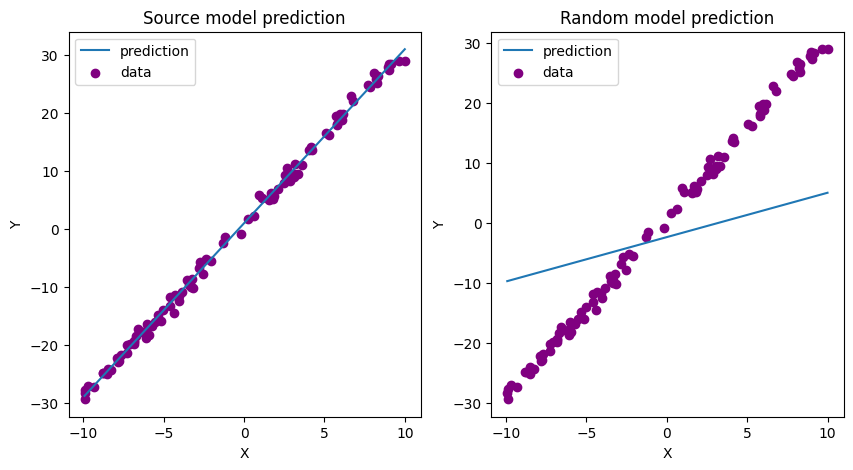

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
plot(x, ax1, y, y_source, title="Source model prediction")
plot(x, ax2, y, y_rand, title="Random model prediction")


## Task 3

In [21]:
import torchvision
from torchvision.transforms import v2
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.IMAGENET1K_V1
model = torchvision.models.resnet18(weights=weights)
model.eval()
categories = weights.meta["categories"]

categories[:10]

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich']

In [65]:
import requests
from io import BytesIO
from PIL import Image

urls = [
    "https://upload.wikimedia.org/wikipedia/commons/4/40/Portrait_of_a_father.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/7/73/Most_Grunwaldzki_Wroclaw_2024_aerial.jpg/1280px-Most_Grunwaldzki_Wroclaw_2024_aerial.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/d/d4/2pac_edit_cropped_further.jpg",
]

images = []
for url in urls:
    headers = {"User-Agent": "NeuralNetworksUniversityProject"}
    r = requests.get(url, headers=headers)
    im = Image.open(BytesIO(r.content))
    images.append(im)

images

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1170x900>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1280x960>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=599x800>]

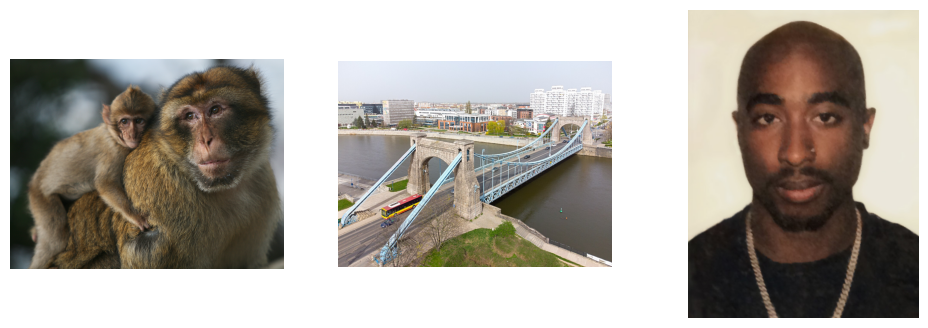

In [66]:
n = len(images)
fig, axes = plt.subplots(1, n, figsize=(12, 4))

for im, ax in zip(images, axes):
    ax.imshow(im)
    ax.axis('off')

In [67]:
transforms = v2.Compose([
    v2.Resize(size=256),
    v2.CenterCrop(size=224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [68]:
out = [transforms(im) for im in images]
out = torch.stack(out)
out.shape

torch.Size([3, 3, 224, 224])

In [69]:
from torch.nn.functional import softmax
res = model(out)

preds = softmax(res, dim=1)
res.shape, preds.shape, torch.sum(res[0])

(torch.Size([3, 1000]),
 torch.Size([3, 1000]),
 tensor(0.0261, grad_fn=<SumBackward0>))

In [70]:
for pred in preds:
    print(torch.sum(pred))

top5 = torch.topk(preds, k=5, dim=1)
top5

tensor(1.0000, grad_fn=<SumBackward0>)
tensor(1., grad_fn=<SumBackward0>)
tensor(1., grad_fn=<SumBackward0>)


torch.return_types.topk(
values=tensor([[0.9605, 0.0064, 0.0063, 0.0062, 0.0061],
        [0.4510, 0.2666, 0.1776, 0.0628, 0.0119],
        [0.1311, 0.1076, 0.0986, 0.0540, 0.0386]], grad_fn=<TopkBackward0>),
indices=tensor([[373, 371, 380, 370, 381],
        [839, 821, 718, 421, 525],
        [457, 568, 652, 834, 715]]))

In [71]:
for i in range(n):
    print(f"---Image {i+1}---")
    probs = top5.values[i]
    ids = top5.indices[i]
    for prob, idx in zip(probs, ids):
        category_name = categories[idx]
        print(f"{category_name}: {prob * 100:.2f}%")

    print()

---Image 1---
macaque: 96.05%
patas: 0.64%
titi: 0.63%
guenon: 0.62%
spider monkey: 0.61%

---Image 2---
suspension bridge: 45.10%
steel arch bridge: 26.66%
pier: 17.76%
bannister: 6.28%
dam: 1.19%

---Image 3---
bow tie: 13.11%
fur coat: 10.76%
military uniform: 9.86%
suit: 5.40%
pickelhaube: 3.86%

